<a href="https://colab.research.google.com/github/gerardkutsukawa/data-analytics-portfolio/blob/main/KutsukawaG_BankChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12 - Bank Churn

---



Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [ ]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Kutsukawa_Churn/data/bank_churn_data.csv')

In [ ]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  int64  
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [ ]:
#### Shape
pdf.shape

(10127, 21)

In [ ]:
#### Null
pdf.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [ ]:
### Duplicate
pdf.duplicated().sum()

0

In [ ]:
#### First 5 rows
pdf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## A. Univariate analysis including histogram and box plot with written description of the following variables:

### i. Customer_Age

In [ ]:
#### i. Customer_Age summary statistics
pdf['Customer_Age'].describe()

count    8101.000000
mean       46.306382
std         8.022527
min        26.000000
25%        41.000000
50%        46.000000
75%        52.000000
max        70.000000
Name: Customer_Age, dtype: float64

<Axes: ylabel='Frequency'>

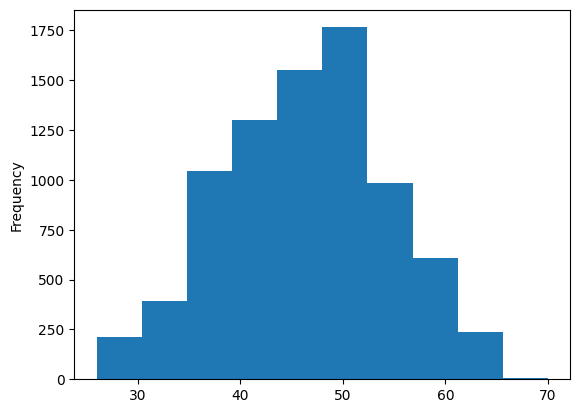

In [ ]:
#### i. Customer_Age histogram
pdf['Customer_Age'].plot(kind='hist')

Based on the histogram, the distribution of customer age is bell-shaped, with a peak around 46 years old. This means most customers fall within the 40-50 year old age range. There is a gradual decline in the number of customers as age increases, with fewer customers below 30 and above 60 years old. While the middle-aged segment is the largest, there might be a missed opportunity to pay attention to younger and older age. I recommend segmenting the customers by age group to understand their behavior, preferences, and churn risk. This will help you develop targeted marketing campaigns and promotions for each segment.


<Axes: >

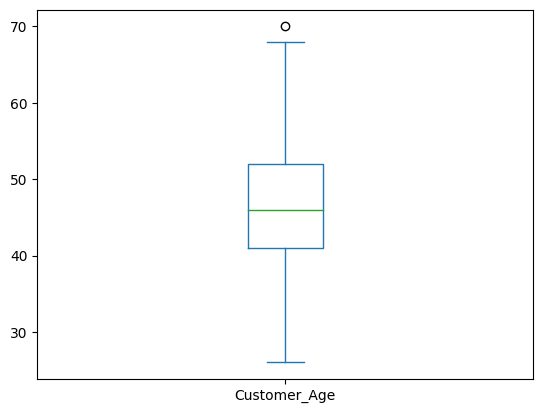

In [ ]:
#### i. Customer_Age boxplot
pdf['Customer_Age'].plot(kind='box')

Based on the box plot, The majority of customers fall between 41 and 52 years old, indicating a concentration in the middle-age, There's a significant drop-off in the number of customers below 30 and above 70, suggesting a smaller presence of younger and older customers. There's only one outlier exceeding 70 years old, highlighting its rarity in the dataset. I recommend to explore expanding your marketing efforts to target younger and older demographics if they align with your business goals.

### ii. Dependent_count

In [ ]:
#### ii. Dependent_count summary statistics
pdf['Dependent_count'].describe()

count    8101.000000
mean        2.334773
std         1.289564
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: Dependent_count, dtype: float64

<Axes: ylabel='Frequency'>

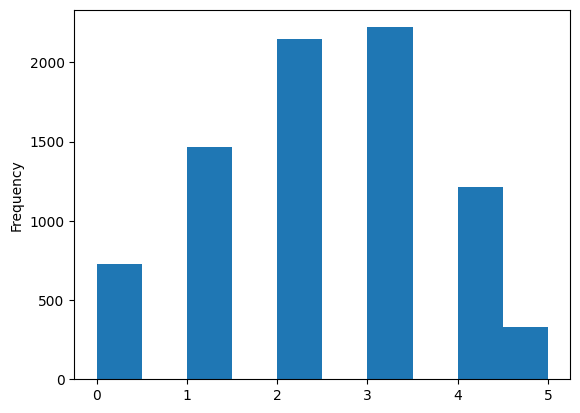

In [ ]:
#### ii. Dependent_count histogram
pdf['Dependent_count'].plot(kind='hist')

Based on the histogram, the most frequent number of dependent cards is 3, with a gradual decrease in the number of customers as the number of dependent cards increases. There are significantly fewer customers with 0 or 5 dependent cards than those with 1 to 4 cards. Customers with more dependent cards might represent families or individuals with higher financial needs, potentially indicating higher spending. They should consider offering loyalty programs or rewards that will give incentives to customers with dependents to spend more or engage with your company more frequently.

<Axes: >

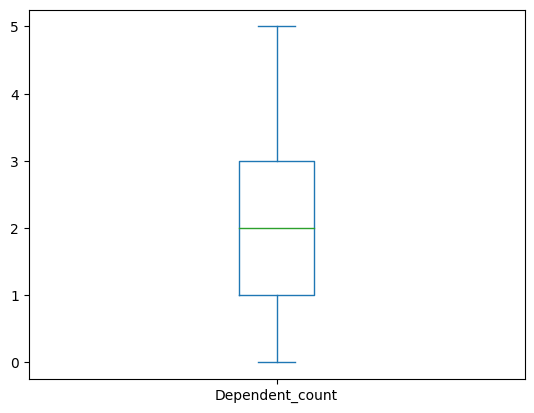

In [ ]:
#### ii. Dependent_count boxplot
pdf['Dependent_count'].plot(kind='box')

Based on the box plot, Most customers have between 1 and 3 dependent cards, indicating that a significant portion of your customer base likely consists of families or individuals with dependents. There are no outliers in the data. I think they should regularly monitor the distribution of dependent cards to identify any emerging trends or shifts in customer behavior.

### iii. Months_Inactive_12_mon

In [ ]:
#### iii. Months_Inactive_12_mon summary statistics
pdf['Months_Inactive_12_mon'].describe()

count    8101.000000
mean        2.346871
std         1.014177
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: Months_Inactive_12_mon, dtype: float64

<Axes: ylabel='Frequency'>

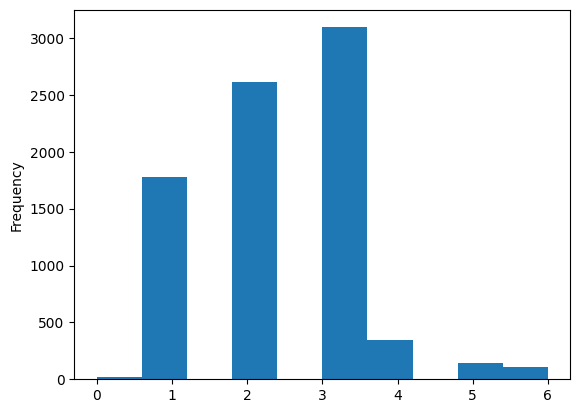

In [ ]:
#### iii. Months_Inactive_12_mon histogram
pdf['Months_Inactive_12_mon'].plot(kind='hist')

Based on the histogram, The highest frequency is 3, and the lowest frequency is 0. There is a lot of frequency in the month of 1 to 3, which means that most customers are inactive in their first 3 months. Also, a few frequencies fall below 500, such as 0, 4, 5, and 6. The initial months after acquisition are crucial for customer engagement and preventing churn. Focusing on reactivating customers who become inactive within the first 3 months could be a valuable strategy to retain your customer base. I recommend to conduct some surveys or focus groups to gather feedback from inactive customers at different timeframes to understand their reasons for inactivity and areas for improvement.

<Axes: >

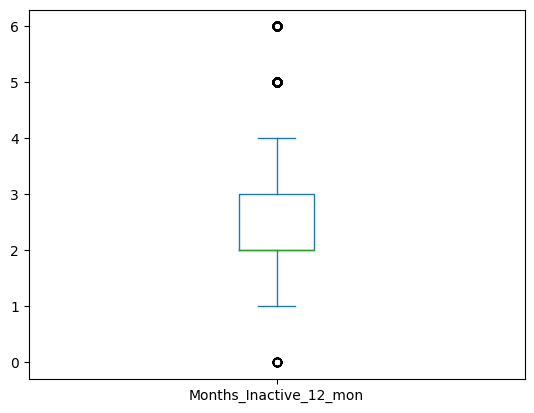

In [ ]:
#### iii. Months_Inactive_12_mon boxplot
pdf['Months_Inactive_12_mon'].plot(kind='box')

Based on the box plot, The max percentile is 4, and the lowest percentile is 1, and most of the customers are inactive in the months of 2 and 3. There are 3 outliers that fall in the month of 0, 5, and 6, so the longest time the customer becomes inactive is 6 months. My takeaway is to design an onboarding process that effectively educates and engages new customers, setting them up for long-term success.

### iv. Credit_Limit

In [ ]:
#### iv. Credit_Limit summary statistics
pdf['Credit_Limit'].describe()

count     8101.000000
mean      8636.548068
std       9086.419557
min       1438.300000
25%       2555.000000
50%       4549.000000
75%      11128.000000
max      34516.000000
Name: Credit_Limit, dtype: float64

<Axes: ylabel='Frequency'>

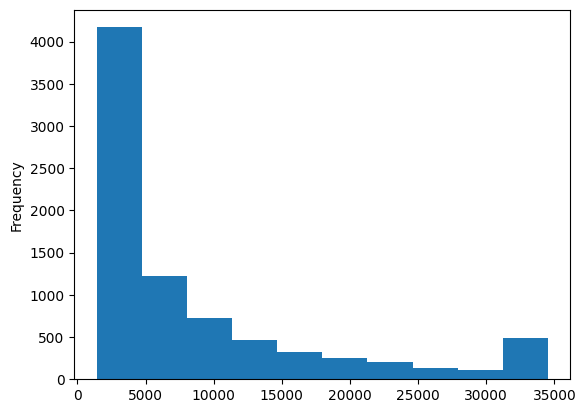

In [ ]:
#### iv. Credit_Limit histogram
pdf['Credit_Limit'].plot(kind='hist')

Based on the histogram, the credit limit distribution is right-skewed, meaning most customers have lower credit limits, with a smaller number having progressively higher limits. The highest frequency range is between 1438.3 and 4549. There's a gradual decrease in the number of customers as the credit limit increases, except for a slight bump at 34516, suggesting a few customers have significantly higher credit limits. I think they should consider offering credit limit increases to customers with a good repayment history and potential for higher spending while ensuring responsible lending practices.

<Axes: >

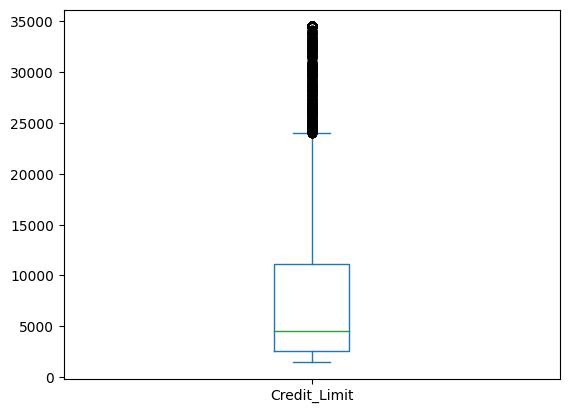

In [ ]:
#### iv. Credit_Limit boxplot
pdf['Credit_Limit'].plot(kind='box')

Based on the box plot, from 2,555 to 11,128, it indicates that the middle 50% of customers have credit limits within this range. There are outliers above 22,000, suggesting that a few customers have significantly higher credit limits than the majority. I recommend analyzing customer behavior to understand their spending patterns and risk profiles rather than relying solely on credit limit data.

### v. Total_Trans_Amt

In [ ]:
#### v. Total_Trans_Amt summary statistics
pdf['Total_Trans_Amt'].describe()

count     8101.000000
mean      4402.988150
std       3401.709545
min        510.000000
25%       2160.000000
50%       3897.000000
75%       4739.000000
max      18484.000000
Name: Total_Trans_Amt, dtype: float64

<Axes: ylabel='Frequency'>

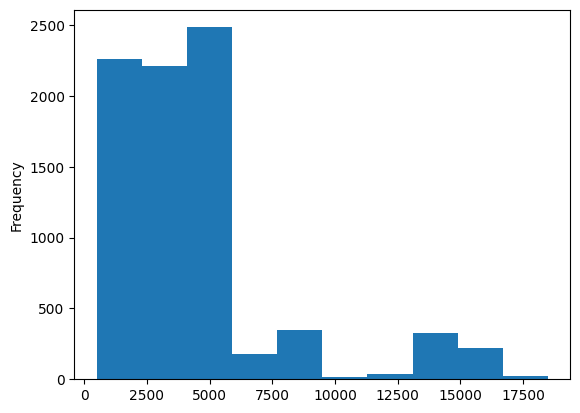

In [ ]:
#### v. Total_Trans_Amt histogram
pdf['Total_Trans_Amt'].plot(kind='hist')

Based on the histogram, the distribution of total transaction amount is right-skewed, meaning most customers have lower transaction amounts, with a smaller number having progressively higher transaction amounts. The highest frequency range is between 2160 and 4739, indicating a concentration of customers within this spending range. Transaction amounts can be valuable for customer segmentation and targeted marketing strategies. I also recommend monitoring customer behavior and spending patterns over time to identify changes and adjust your segmentation and marketing strategies accordingly.

<Axes: >

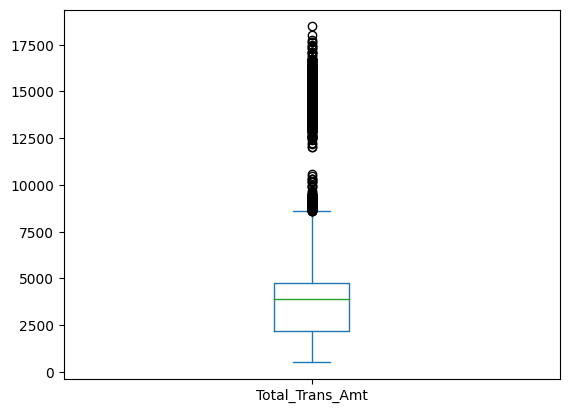

In [ ]:
#### v. Total_Trans_Amt box plot
pdf['Total_Trans_Amt'].plot(kind='box')

Based on the box plot, Most transaction amounts fall between 2160 and 4739, indicating a concentration of customers within this spending range. There are outliers exceeding 10,000, suggesting a small number of customers with significantly higher transaction amounts. Also, the presence of outliers highlights the need to consider them separately when analyzing spending patterns. The distribution of transaction amounts is right-skewed. They should consider implementing fraud detection mechanisms to monitor suspicious transactions, especially those exceeding typical spending patterns.

## B. Univariate analysis including bar plot with written description for:

### i. Attrion_Flag

In [ ]:
#### i. Count Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts()

0    6801
1    1300
Name: Attrition_Flag, dtype: int64

<Axes: >

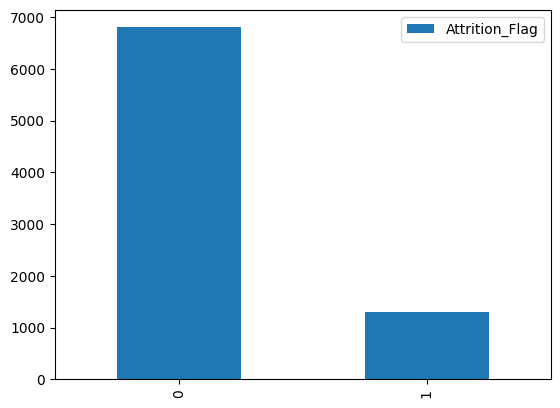

In [ ]:
#### i. Plot Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts().plot(kind='bar', legend=True)

Based on the graph, there are a lot of customers who stay with the company, and there are a few customers who left the company. The outcome of the data is positive because the company is doing an excellent job of retaining customers. I recommend conducting regular customer satisfaction surveys to understand why customers stay with the company and what could be improved.

## C. Bivariate analysis including descriptive statistics and bar plot with written description for the following pair of variables:

### Descriptive Statistics

In [ ]:
#### Descriptive statistics
pdf[['Customer_Age', 'Dependent_count', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt']].describe()

,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
count,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,46.306382,2.334773,2.346871,8636.548068,4402.988150
std,8.022527,1.289564,1.014177,9086.419557,3401.709545
min,26.000000,0.000000,0.000000,1438.300000,510.000000
25%,41.000000,1.000000,2.000000,2555.000000,2160.000000
50%,46.000000,2.000000,2.000000,4549.000000,3897.000000
75%,52.000000,3.000000,3.000000,11128.000000,4739.000000
max,70.000000,5.000000,6.000000,34516.000000,18484.000000


### i. Customer_Age vs Attrition_Flag

In [ ]:
#### i. mean of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age']

Attrition_Flag
0    46.182914
1    46.952308
Name: Customer_Age, dtype: float64

<Axes: xlabel='Attrition_Flag'>

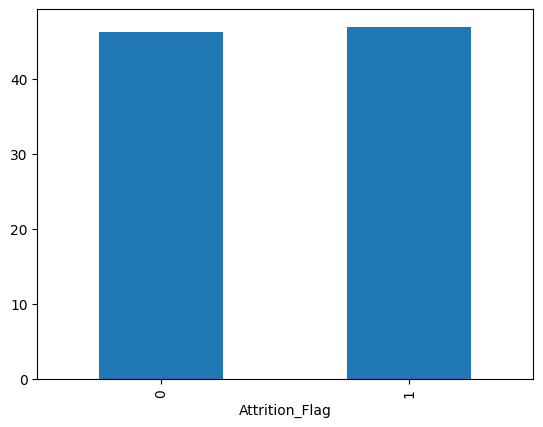

In [ ]:
#### i. Bar Plot Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age'].plot(kind='bar')

Based on the plot, Customers who left the company (attrition flag of 1) tend to be a little older than customers who stayed (attrition flag of 0). The comparison between the average age of customers who remain and those who left the company is almost exactly the same. My recommendation is to conduct further analysis to identify other factors that are correlated with customer churn.

### ii. Dependent_count vs Attrition_Flag

In [ ]:
#### ii. mean Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Dependent_count']

Attrition_Flag
0    2.323188
1    2.395385
Name: Dependent_count, dtype: float64

<Axes: xlabel='Attrition_Flag'>

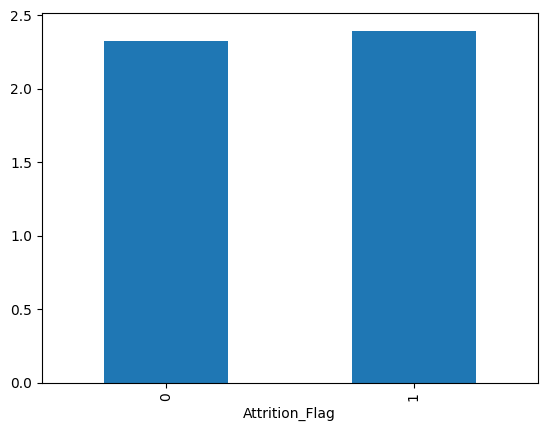

In [ ]:
#### ii. Bar Plot Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Dependent_count'].plot(kind='bar')

Customers who left the company (attrition flag = 1) tend to have a slightly higher average number of dependent cards (2.40) compared to customers who stay (attrition flag = 0) (2.32). The distribution of the number of dependent cards is similar for both groups, with most customers having 1-3 dependent cards. This suggests that the relationship between the number of dependent cards and churn is not very strong. I recommend segmenting your customers by the number of dependent cards and analyzing their churn rates. This will help you determine if there is a statistically significant relationship between the two variables.

### iii. Months_Inactive_12_mon vs Attrition_Flag

In [ ]:
#### iii. mean Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Months_Inactive_12_mon']

Attrition_Flag
0    2.277459
1    2.710000
Name: Months_Inactive_12_mon, dtype: float64

<Axes: xlabel='Attrition_Flag'>

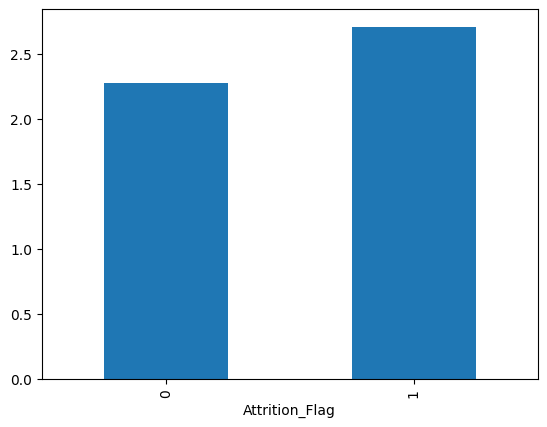

In [ ]:
#### iii. Bar Plot Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Months_Inactive_12_mon'].plot(kind='bar')

Customers who left the company (attrition flag 1) tend to be inactive for longer than those who stayed (attrition flag 0), and customers who left the company show a steeper increase in inactivity duration, indicating a more decisive shift away from using the product. I think they should implement a system to monitor customer activity and identify customers who are becoming inactive.

### iv. Credit_Limit vs Attrition_Flag

In [ ]:
#### iv. mean Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Credit_Limit']

Attrition_Flag
0    8733.619453
1    8128.715385
Name: Credit_Limit, dtype: float64

<Axes: xlabel='Attrition_Flag'>

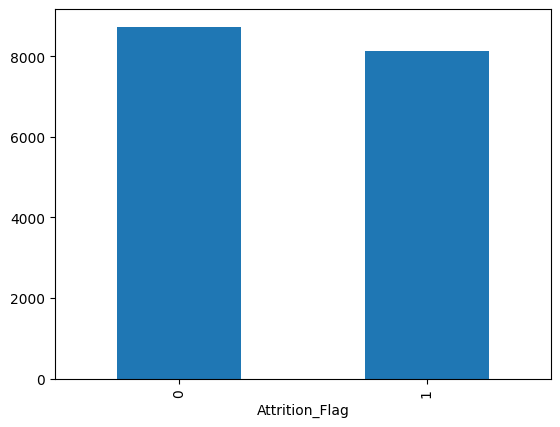

In [ ]:
#### iv. Bar Plot Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Credit_Limit'].plot(kind='bar')

Based on the plot, it shows that there is a slight difference in the average credit limit between customers who stayed (attrition flag 0) and those who left (attrition flag 1). Customers who stayed have a slightly higher average credit limit (8733.62) compared to those who left (8128.72). While there is a difference, it's relatively small and might not be statistically significant. In this case, credit limit alone may not be a strong indicator of customer churn.

### v. Total_Trans_Amt vs Attrition_Flag

In [ ]:
#### v. mean Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Total_Trans_Amt']

Attrition_Flag
0    4667.816939
1    3017.526154
Name: Total_Trans_Amt, dtype: float64

<Axes: xlabel='Attrition_Flag'>

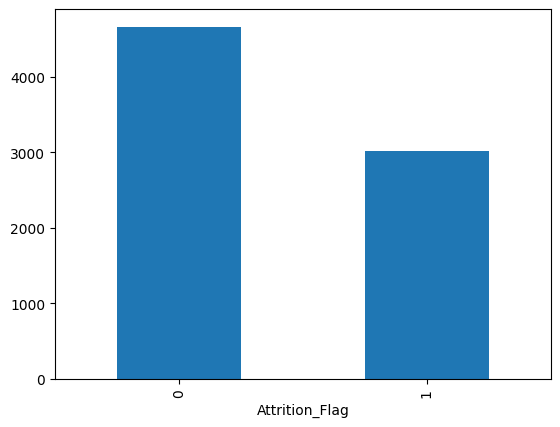

In [ ]:
#### v. Bar Plot Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Total_Trans_Amt'].plot(kind='bar')

Based on the plot, customers who left the company (attrition flag 1) tend to have a lower average total transaction amount than those who stayed (attrition flag 0). This suggests that customers spending less money with the company are likelier to churn. The transaction amount could be a valuable indicator for predicting customer churn. I also recommend to offer some incentives or rewards to customers who increase their total transaction amount, such as discounts, loyalty points, or exclusive benefits, to encourage them to spend more and to retain the customers.